In [1]:
!pip install matplotlib seaborn pandas numpy

In [2]:
# magic command to display matplotlib plots inline within the ipython notebook webpage
%matplotlib inline

# import necessary modules
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.cm as cm, matplotlib.font_manager as fm

In [6]:
# load the gps coordinate data, using the date as the full set's index
# the data files are encoded as utf-8: specify so to prevent matplotlib from choking on diacritics
df = pd.read_csv('data/summer-travel-gps-full.csv', encoding='utf-8', index_col='date', parse_dates=True)
rs = pd.read_csv('data/summer-travel-gps-dbscan.csv', encoding='utf-8')

In [7]:
df.head()

,lat,lon,city,country
date,,,,
2014-05-14 09:07:00,51.481292,-0.451011,West Drayton,United Kingdom
2014-05-14 09:22:00,51.474005,-0.450999,Hounslow,United Kingdom
2014-05-14 10:51:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:24:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:38:00,51.474146,-0.451562,Hounslow,United Kingdom


In [8]:
rs.head()

,lat,lon,date,city,country
0,51.478199,-0.446081,05/14/2014 10:51,Hounslow,United Kingdom
1,38.781775,-9.137544,05/14/2014 15:11,Lisbon,Portugal
2,38.771939,-9.128911,05/14/2014 15:41,Lisbon,Portugal
3,38.742987,-9.147780,05/14/2014 16:11,Lisbon,Portugal
4,38.693780,-9.206363,05/15/2014 14:19,Lisbon,Portugal


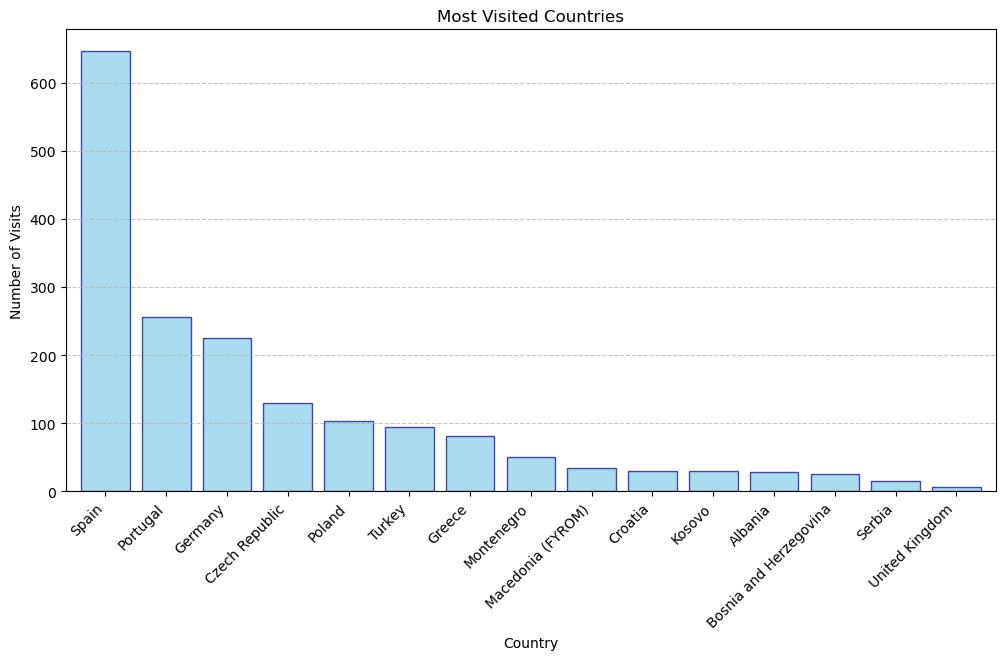

In [10]:
# Q1: Can you draw a bar chart for the most visited countries by using matplotlib and seaborn? You can use the df dataframe.
# Please style the chart to make it look nicer
# such as figsize, width, alpha, color, edgecolor, grid, xlim, and ylim
country_counts = df['country'].value_counts()
plt.figure(figsize=(12, 6))
ax = country_counts.plot(kind='bar', 
                         color='skyblue', 
                         edgecolor='navy', 
                         width=0.8, 
                         alpha=0.7)
ax.set_xlabel('Country')
ax.set_ylabel('Number of Visits')
ax.set_title('Most Visited Countries')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

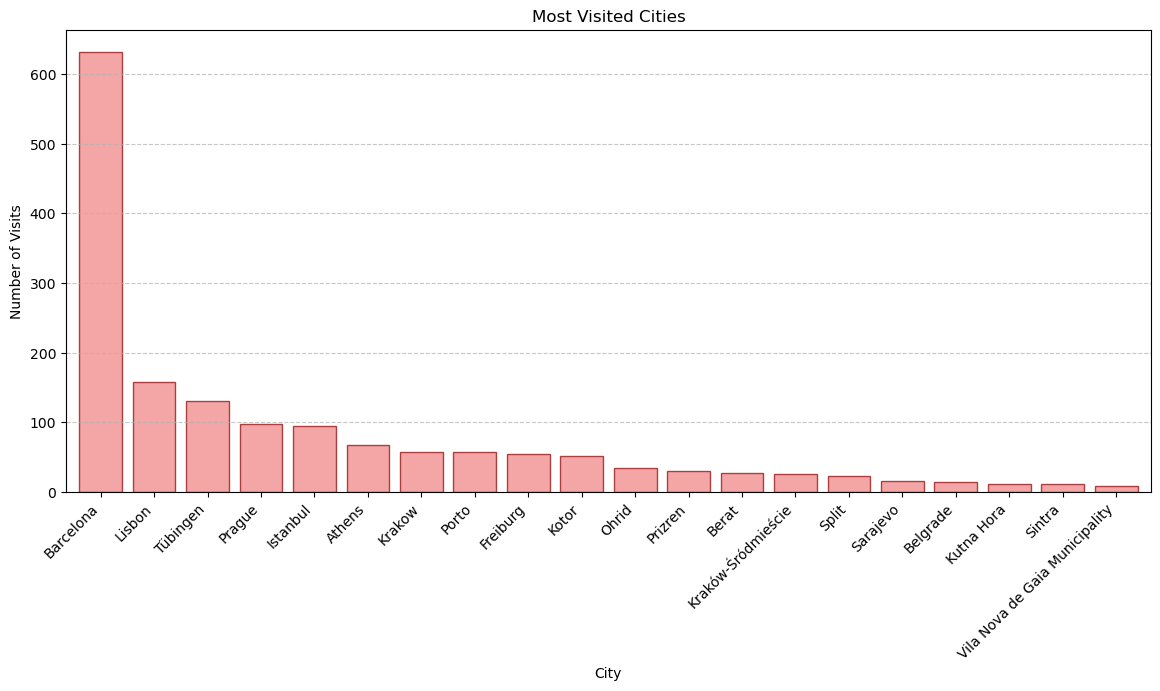

In [11]:
# Q2: Draw the same bar chart, but now for the most visited cities instead of countries
city_counts = df['city'].value_counts().head(20)
plt.figure(figsize=(14, 6))
ax = city_counts.plot(kind='bar', 
                       color='lightcoral', 
                       edgecolor='darkred', 
                       width=0.8, 
                       alpha=0.7)

ax.set_xlabel('City')
ax.set_ylabel('Number of Visits')
ax.set_title('Most Visited Cities')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

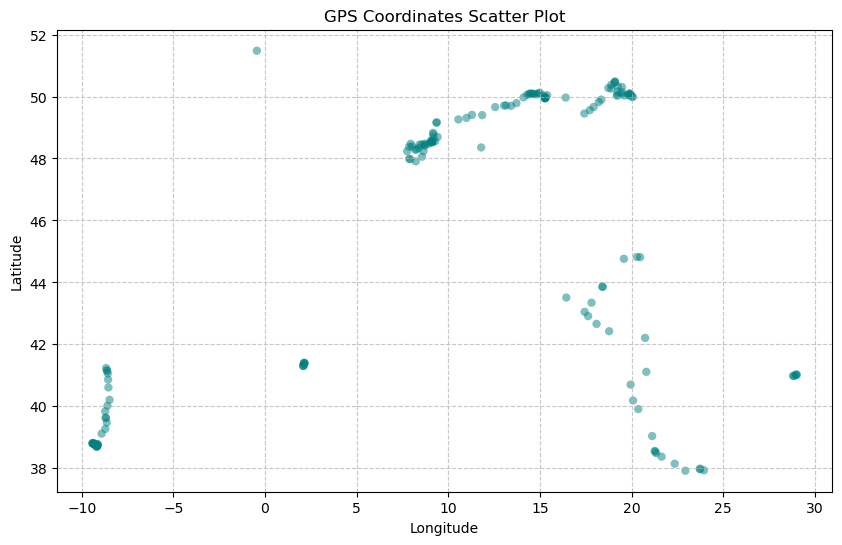

In [13]:
# Q3: Draw a scatter plot the longitude and latitude data, with matplotlib and seaborn defaults. 
# You can use the rs dataframe.
# Please style the chart to make it look nicer with good size and alpha settings. 
plt.figure(figsize=(10, 6))
plt.scatter(rs['lon'], rs['lat'], alpha=0.5, color='teal', edgecolor='none')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('GPS Coordinates Scatter Plot')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [14]:
# get the count of records by date
countdata = df.groupby(df.index.date).size()
countdata.head()

2014-05-14    36
2014-05-15    61
2014-05-16    57
2014-05-17    64
2014-05-18    50
dtype: int64

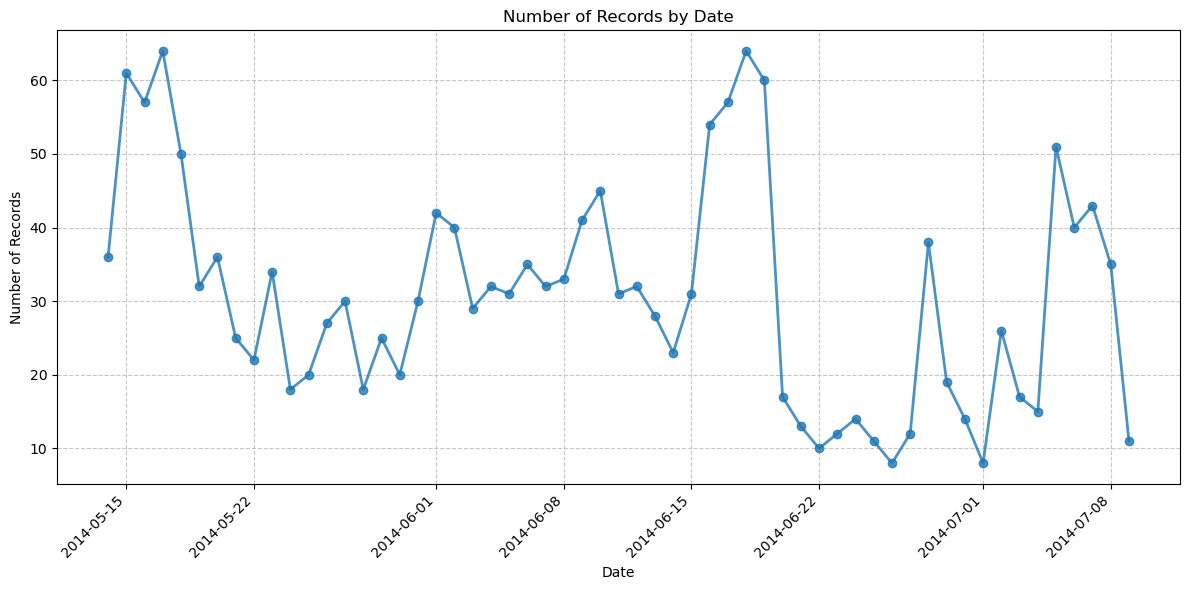

In [15]:
# Q4: Draw a  matplotlib and seaborn line chart from countdata. 
# Please style the chart to make it look nicer with good size and alpha settings. 
plt.figure(figsize=(12, 6))
plt.plot(countdata.index, countdata.values, marker='o', linewidth=2, markersize=6, alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Number of Records')
plt.title('Number of Records by Date')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

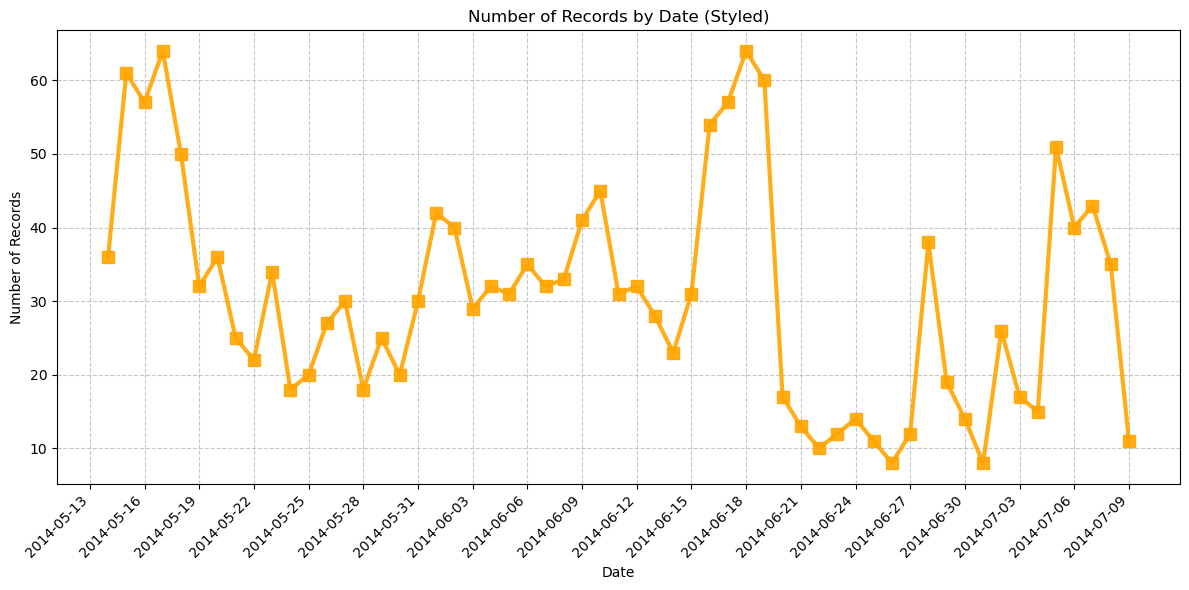

In [16]:
# Q5: Now you try: re-create the plot above with different line widths, colors, and point markers. 
# Play with moving the annotation labels around. Make the vertical tick marks 3 days apart instead of 5.
plt.figure(figsize=(12, 6))
plt.plot(countdata.index, countdata.values, marker='s', linewidth=3, markersize=8, alpha=0.9, color='orange')
plt.xlabel('Date')
plt.ylabel('Number of Records')
plt.title('Number of Records by Date (Styled)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(3))
plt.tight_layout()
plt.show()

In [19]:
cities = df['city'].value_counts()
print(cities.count())
cities.head()

113


city
Barcelona    632
Lisbon       158
Tübingen     131
Prague        97
Istanbul      94
Name: count, dtype: int64

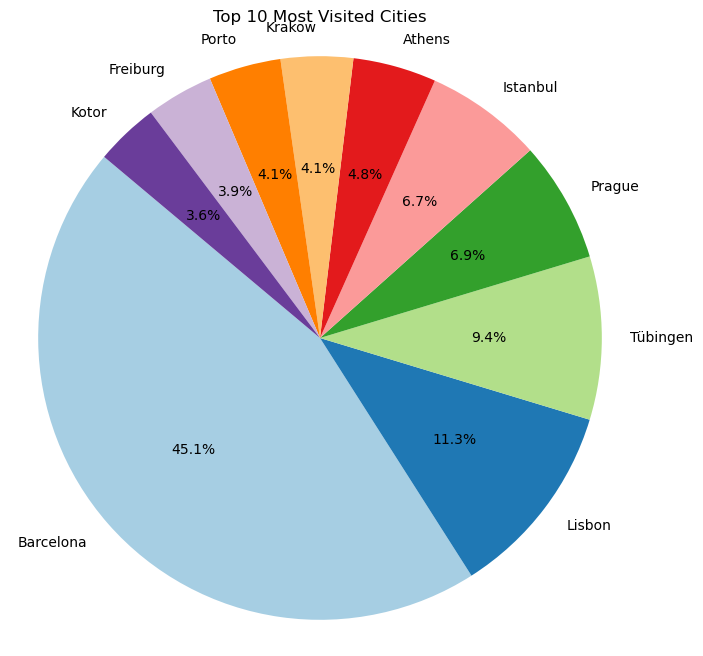

In [20]:
# Q6: draw a pie chart for cities.
plt.figure(figsize=(8, 8))
cities.head(10).plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=cm.Paired.colors)
plt.title('Top 10 Most Visited Cities')
plt.ylabel('')
plt.axis('equal')
plt.show()